# Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

# Task 0 Theoretical proof: (0.5 points)


Task 0 proof that Bellman optimality equation has a unique solutions and iterative policy evaluation can converge to it.

For prooving this we can use a Banach fixed point theorem and using the fact that Bellman operator is a contraction.
### Banach Fixed-Point Theorem (Contraction Mapping Theorem)


Let $(X, d)$ be a **non-empty complete metric space**.

A mapping $T: X \to X$ is called a **contraction** (or contraction mapping or operator) if there exists a constant $q \in [0, 1)$ such that for all $x, y \in X$:
$$
d(T(x), T(y)) \le q \cdot d(x, y)
$$

The constant $q$ is known as the **Lipschitz constant** or the **contraction factor**.
## Banach fixed point theorem
If $T: X \to X$ is a contraction on a non-empty complete metric space $(X, d)$, then:

 **Existence and Uniqueness:** $T$ has exactly one fixed point $x^* \in X$. That is, there exists a unique $x^*$ such that:
    $$
    T(x^*) = x^*
    $$

**Convergence:** For any initial point $x_0 \in X$, the sequence defined by the iteration:
    $$
    x_{n+1} = T(x_n), \quad n = 0, 1, 2, \dots
    $$
    converges to $x^*$.




The only thing that is left to proove is that Bellman optimality operator B is contraction mapping:


$B^{\pi}(v^{∗}) = max_{\pi}(r_{\pi}+\gamma P_{\pi}v^{*})$ 
Proove this here: 

#TODO:

You should prove that 
$$
\|B^{\pi}(V_1) - B^{\pi}(V_2)\|_\infty \leq \alpha \|(V_1) - (V_2)\|_\infty 
$$
 $0<\alpha<1$

Where **max norm** also known as the **infinity norm**, **supremum norm**

For a vector $x = [x_1, x_2, \dots, x_n] \in \mathbb{R}^n$, the max norm is defined as the maximum absolute value among its components:

$$
\|x\|_\infty = \max_{i \in \{1, \dots, n\}} |x_i|
$$


## Your proof here(you can a photo of your written  notes ot use markdown)

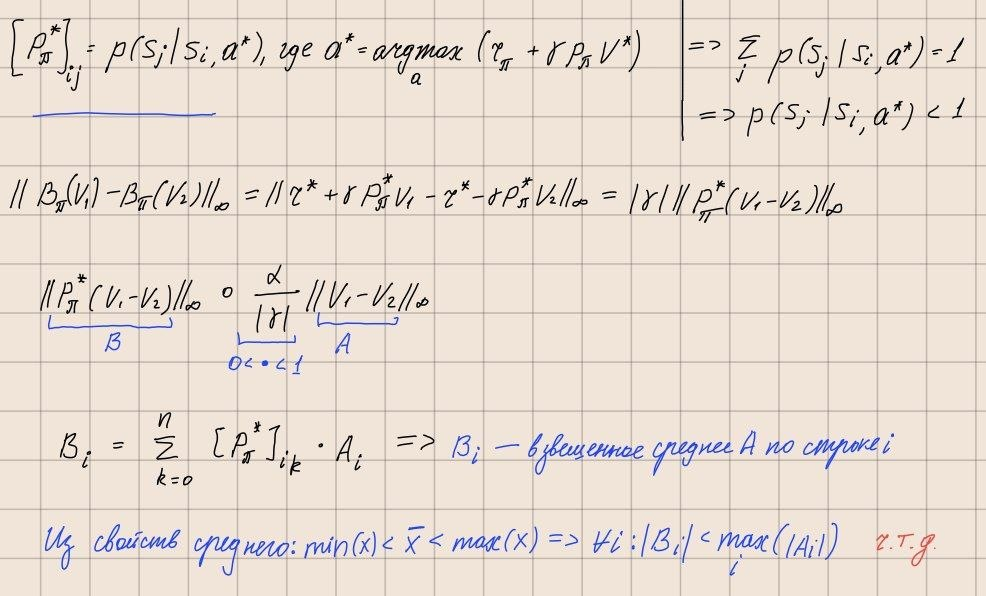

In [48]:
from IPython.display import Image, display
display(Image(filename="data/task0_value_based.jpg"))

# Task 1: Write a code of MDP based on this schema and description: (1 point)
Imagine you are Cobb.  Every time you go deeper into a dream, things get more unstable. If you mess up, you end up in Limbo.
## The Setup of the MDP
### States: You start on the Plane (S0). You can dive into Level 1 (S1), Level 2 (S2), or Level 3 (S3).
### Goal: Reach Success (S4) by planting the idea.
Main Danger: If you fail, you hit Failure (S5) and the game is  over.

### The Actions: 
1) Go Deeper 
2) ​Stabilize 

3) Abort/Kick Up 
​


![Pasted Graphic.png](<attachment:Pasted Graphic.png>)

In [ ]:
import numpy as np
from enum import IntEnum
from dataclasses import dataclass
from typing import List, Tuple


class STATE(IntEnum):

    REALITY = 0
    LEVEL_1 = 1
    LEVEL_2 = 2
    LEVEL_3 = 3
    SUCCESS = 4
    FAILURE = 5


class ACTION(IntEnum):
    GO_DEEPER = 0
    STABILIZE = 1
    ABORT = 2


@dataclass
class Transition:

    probability: float
    next_state: STATE
    reward: float


class InceptionMDP:

    def __init__(self):
        self.n_states = len(STATE)
        self.n_actions = len(ACTION)

        # store dynamics: dynamics[state][action] = List[Transition]
        self.dynamics = {s: {a: [] for a in ACTION} for s in STATE}

        self._setup_movie_logic()

    def _add_rule(
        self,
        state: STATE,
        action: ACTION,
        prob: float,
        next_state: STATE,
        reward: float,
    ):
        """Helper to add a transition rule cleanly."""
        self.dynamics[state][action].append(Transition(prob, next_state, reward))

    def _setup_movie_logic(self):
        """
        Defines the probabilities and rewards based on the movie plot.
        """

        self._add_rule(STATE.REALITY, ACTION.GO_DEEPER, 1.0, STATE.LEVEL_1, 0)

        self._add_rule(STATE.REALITY, ACTION.STABILIZE, 1.0, STATE.REALITY, -1)
        self._add_rule(STATE.REALITY, ACTION.ABORT, 1.0, STATE.REALITY, -1)

        self._add_rule(STATE.LEVEL_1, ACTION.GO_DEEPER, 0.8, STATE.LEVEL_2, 0)
        self._add_rule(STATE.LEVEL_1, ACTION.GO_DEEPER, 0.2, STATE.FAILURE, -10)

        self._add_rule(STATE.LEVEL_1, ACTION.STABILIZE, 0.9, STATE.LEVEL_1, -1)
        self._add_rule(STATE.LEVEL_1, ACTION.STABILIZE, 0.1, STATE.FAILURE, -10)

        self._add_rule(STATE.LEVEL_1, ACTION.ABORT, 1.0, STATE.REALITY, -2)

        self._add_rule(STATE.LEVEL_2, ACTION.GO_DEEPER, 0.7, STATE.LEVEL_3, 0)
        self._add_rule(STATE.LEVEL_2, ACTION.GO_DEEPER, 0.3, STATE.FAILURE, -10)

        self._add_rule(STATE.LEVEL_2, ACTION.STABILIZE, 0.85, STATE.LEVEL_2, -1)
        self._add_rule(STATE.LEVEL_2, ACTION.STABILIZE, 0.15, STATE.LEVEL_1, -1)

        self._add_rule(STATE.LEVEL_2, ACTION.ABORT, 1.0, STATE.LEVEL_1, -2)



        self._add_rule(STATE.LEVEL_3, ACTION.GO_DEEPER, 0.4, STATE.LEVEL_3, 0)
        self._add_rule(STATE.LEVEL_3, ACTION.GO_DEEPER, 0.4, STATE.FAILURE, -10)
        self._add_rule(STATE.LEVEL_3, ACTION.GO_DEEPER, 0.2, STATE.SUCCESS, 10)

        self._add_rule(STATE.LEVEL_3, ACTION.STABILIZE, 0.9, STATE.LEVEL_3, -1)
        self._add_rule(STATE.LEVEL_3, ACTION.STABILIZE, 0.1, STATE.FAILURE, -10)

        self._add_rule(STATE.LEVEL_3, ACTION.ABORT, 1.0, STATE.LEVEL_1, -2)

        for term_state in [STATE.SUCCESS, STATE.FAILURE]:
            for act in ACTION:
                self._add_rule(term_state, act, 1.0, term_state, 0)

    def get_possible_outcomes(self, state: STATE, action: ACTION) -> List[Transition]:
        return self.dynamics[state][action]

    def step(self, state: STATE, action: ACTION) -> Tuple[STATE, float, bool]:
        state = STATE(int(state))
        action = ACTION(int(action))

        if state in [STATE.SUCCESS, STATE.FAILURE]:
            return state, 0.0, True

        outcomes = self.get_possible_outcomes(state, action)

        probs = [t.probability for t in outcomes]
        choices = [(t.next_state, t.reward) for t in outcomes]

        idx = np.random.choice(len(choices), p=probs)
        next_state, reward = choices[int(idx)]
        is_terminal = next_state in [STATE.SUCCESS, STATE.FAILURE]

        return next_state, reward, is_terminal



## Initializing environment

In [2]:
env = InceptionMDP()


In [ ]:
import random
import numpy as np


class ExampleRandomAgent:
    """Baseline from the notebook: go deeper from reality, else uniform random."""

    def __init__(self, n_states=len(STATE), n_actions=len(ACTION)):
        self.n_states = n_states
        self.n_actions = n_actions

    def get_action(self, state):
        if state == STATE.REALITY:
            return ACTION.GO_DEEPER
        return random.choice((ACTION.GO_DEEPER, ACTION.STABILIZE, ACTION.ABORT))

agent = ExampleRandomAgent()

In [5]:
def play_inception_game(env, agent):
    current_state = STATE.REALITY
    total_reward = 0
    step_count = 0

    # Uses whatever `agent` is (e.g. ExampleRandomAgent or optimal PolicyAgent from later cells).
    while current_state not in [STATE.SUCCESS, STATE.FAILURE] and step_count < 10:
        action = agent.get_action(current_state)
        next_state, reward, done = env.step(current_state, action)

        print(f"Step {step_count+1}: From {current_state.name} : [{action.name}] to  {next_state.name} with Reward: {reward}")

        current_state = next_state
        total_reward += reward
        step_count += 1
    print(f"Ended in {current_state.name}. Total Reward: {total_reward}")


### Play the game 

In [6]:
play_inception_game(env, agent)

Step 1: From REALITY : [GO_DEEPER] to  LEVEL_1 with Reward: 0
Step 2: From LEVEL_1 : [ABORT] to  REALITY with Reward: -2
Step 3: From REALITY : [GO_DEEPER] to  LEVEL_1 with Reward: 0
Step 4: From LEVEL_1 : [ABORT] to  REALITY with Reward: -2
Step 5: From REALITY : [GO_DEEPER] to  LEVEL_1 with Reward: 0
Step 6: From LEVEL_1 : [GO_DEEPER] to  LEVEL_2 with Reward: 0
Step 7: From LEVEL_2 : [GO_DEEPER] to  LEVEL_3 with Reward: 0
Step 8: From LEVEL_3 : [GO_DEEPER] to  LEVEL_3 with Reward: 0
Step 9: From LEVEL_3 : [ABORT] to  LEVEL_1 with Reward: -2
Step 10: From LEVEL_1 : [STABILIZE] to  LEVEL_1 with Reward: -1
Ended in LEVEL_1. Total Reward: -7


In [7]:
# Propose another policy better than the example policy

# логичным будет всегда делать GO_DEEPER
class PolicyAgent:
    def __init__(self, env: InceptionMDP, gamma: float = 0.9):
        self.env = env
        self.gamma = gamma
        self.n_states = len(STATE)
        self.n_actions = len(ACTION)

    def get_action(self, state: STATE) -> ACTION:
        return ACTION.GO_DEEPER


agent = PolicyAgent(env)



In [52]:
play_inception_game(env, agent)

Step 1: From REALITY : [GO_DEEPER] to  LEVEL_1 with Reward: 0
Step 2: From LEVEL_1 : [GO_DEEPER] to  LEVEL_2 with Reward: 0
Step 3: From LEVEL_2 : [GO_DEEPER] to  LEVEL_3 with Reward: 0
Step 4: From LEVEL_3 : [GO_DEEPER] to  SUCCESS with Reward: 10
Ended in SUCCESS. Total Reward: 10


удачный запуск

# Task 2 
Let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

# Here use mdp.py attached in github

In [9]:
!pip install gdown


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [10]:
!gdown https://drive.google.com/uc?id=1gyhaOg7TeRU1Hiq0vLR6ib98oDRaT1mo

zsh:1: no matches found: https://drive.google.com/uc?id=1gyhaOg7TeRU1Hiq0vLR6ib98oDRaT1mo


In [11]:
import numpy as np
import matplotlib.pyplot as plt

from time import sleep
from mdp import MDP, has_graphviz, FrozenLakeEnv
from IPython.display import display, clear_output

%matplotlib inline

In [12]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

We can now use MDP just as any other gym environment:

In [13]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [14]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ",
      mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. For ubuntu just run:

1. `sudo apt-get install graphviz`
2. `pip install graphviz`
3. restart the notebook

For windows this might work: `conda install -c conda-forge python-graphviz`. However, you can ignore this part alltogether and use the standard vizualization.

In [15]:
print("Graphviz available:", has_graphviz)

Graphviz available: True


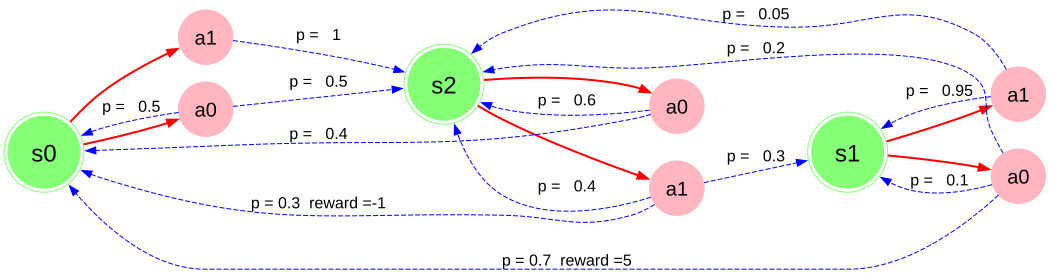

In [16]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, \
        plot_graph_optimal_strategy_and_state_values

    display(plot_graph(mdp))

# Task 3: Value Iteration (up to 1 point)

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max\limits_a \sum\limits_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^*$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [17]:
%%writefile mdp_get_action_value.py
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """

    q = 0
    for next_state, ps in mdp.get_next_states(state, action).items():
        r = mdp.get_reward(state, action, next_state)
        q += ps * (r + gamma * state_values[next_state])
        
    return q


Overwriting mdp_get_action_value.py


In [18]:
from mdp_get_action_value import get_action_value

test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [19]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0

    best_q = None
    for a in mdp.get_possible_actions(state):
        q = get_action_value(mdp, state_values, state, a, gamma)
        best_q = max(best_q, q) if best_q else q


    return best_q

In [20]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert test_Vs == test_Vs_copy, "please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

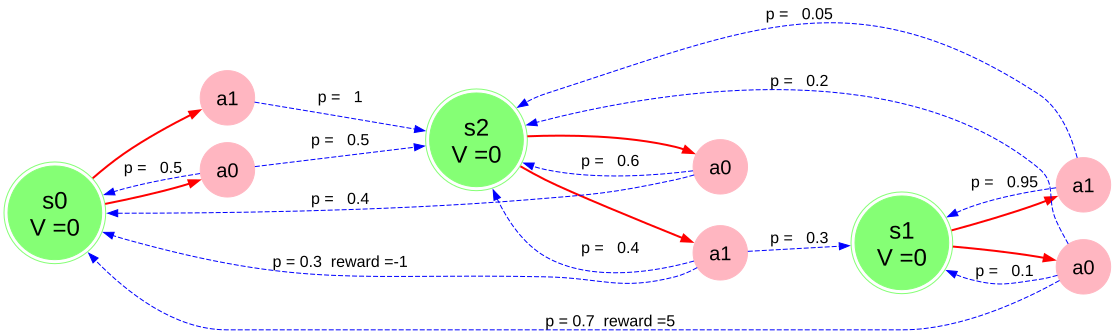

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.83700   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = -0.300
iter    2   |   diff: 0.61830   |   V(s0) = -0.135   V(s1) = 3.761   V(s2) = 0.537
iter    3   |   diff: 0.45791   |   V(s0) = 0.483   V(s1) = 3.850   V(s2) = 0.872
iter    4   |   diff: 0.31734   |   V(s0) = 0.785   V(s1) = 4.308   V(s2) = 1.184
iter    5   |   diff: 0.28561   |   V(s0) = 1.066   V(s1) = 4.595   V(s2) = 1.501
iter    6   |   diff: 0.25148   |   V(s0) = 1.351   V(s1) = 4.855   V(s2) = 1.769
iter    7   |   diff: 0.22062   |   V(s0) = 1.592   V(s1) = 5.107   V(s2) = 2.013
iter    8   |   diff: 0.19855   |   V(s0) = 1.811   V(s1) = 5.325   V(s2) = 2.233
iter    9   |   diff: 0.17842   |   V(s0) = 2.010   V(s1) = 5.522   V(s2) = 2.431
iter   10   |   diff: 0.16026   |   V(s0) = 2.188   V(s1) = 5.701   V(s2) = 2.609
iter   11   |   diff: 0.14424   |   V(s0) = 2.348   V(s1) = 5.861   V(s2) = 2.769
iter   12   | 

In [21]:
# parameters
gamma = 0.9  # discount for MDP
num_iter = 100  # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    new_state_values = {
        state: get_new_state_value(mdp, state_values, state, gamma)
        for state in state_values
    }

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print("   ".join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

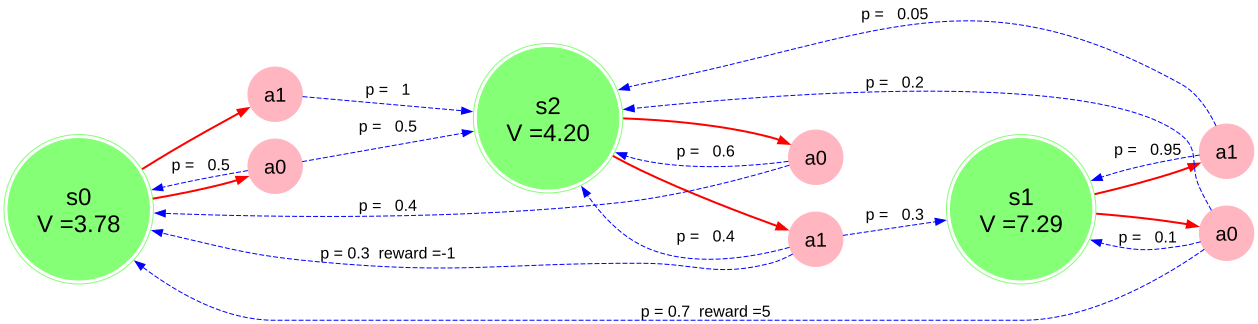

In [22]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [23]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7816909249269743, 's1': 7.294662475246563, 's2': 4.202796326606383}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = \underset{a}{\operatorname{argmax}} \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \underset{a}{\operatorname{argmax}} Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [24]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """Finds optimal action using formula above."""
    if mdp.is_terminal(state):
        return None

    best_action = None
    best_q = None

    for a in mdp.get_possible_actions(state):
        q = get_action_value(mdp, state_values, state, a, gamma)

        if best_q is None or q > best_q:
            best_q = q
            best_action = a

    return best_action

In [25]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

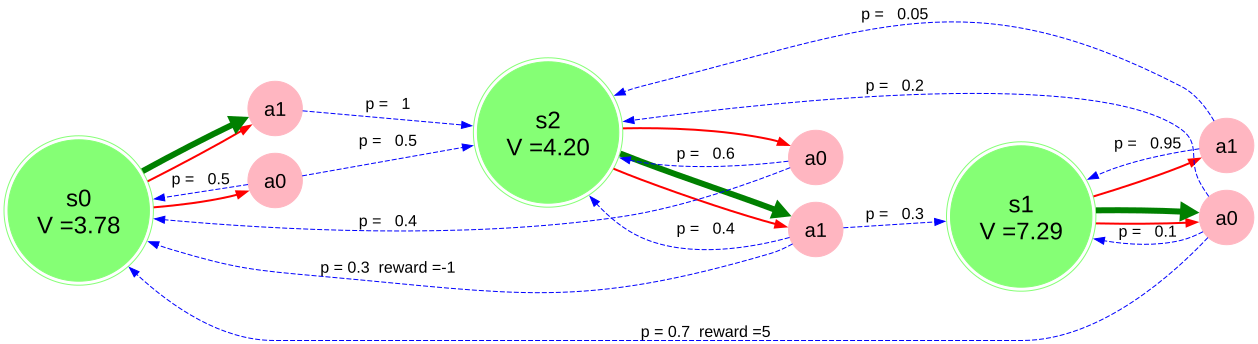

In [26]:
if has_graphviz:
    try:
        display(plot_graph_optimal_strategy_and_state_values(mdp, state_values))
    except ImportError:
        raise ImportError("Run the cell that starts with \"%%writefile mdp_get_action_value.py\"")

In [27]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4651


### Frozen lake

In [28]:
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [29]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        new_state_values = {state: get_new_state_value(mdp, state_values, state, gamma) for state in state_values}

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [30]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [31]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [32]:


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (-1, 0)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


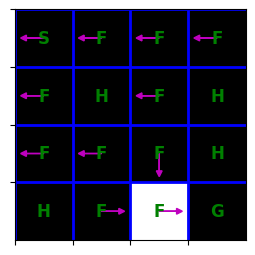

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


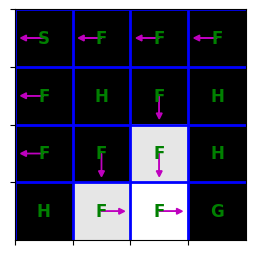

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


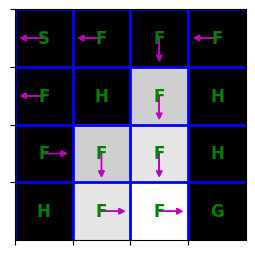

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


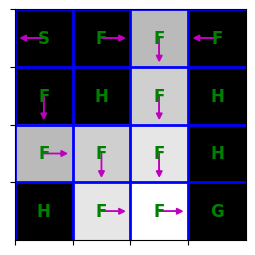

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


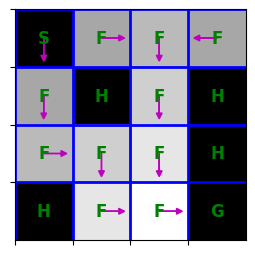

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


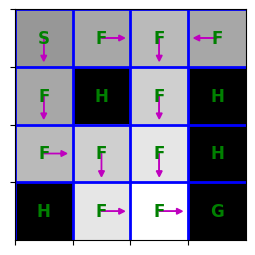

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


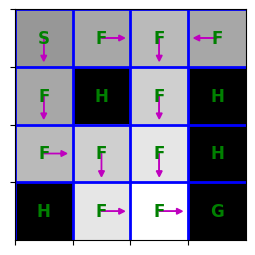

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


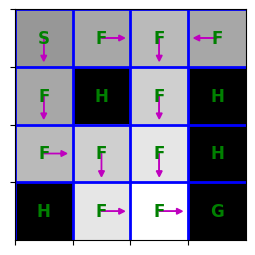

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


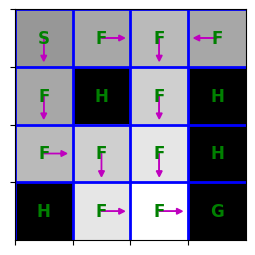

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


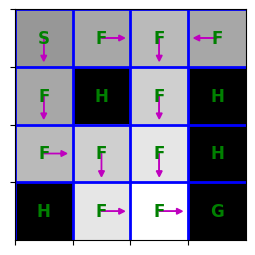

In [33]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


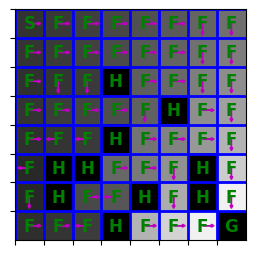

In [34]:
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [35]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [36]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.876
Well done!


In [37]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [38]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# Task 4 Policy Iteration (up to 1 points)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \underset{a}{\operatorname*{argmax}} Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [39]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve` or fixed-point iteration method.)

In [40]:
def compute_vpi(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """

    states = mdp.get_all_states()
    n = len(states)
    P = np.zeros((n, n))
    r_pi = np.zeros(n)
    for i, s in enumerate(states):
        if mdp.is_terminal(s):
            continue
        for j, s_next in enumerate(states):
            p = mdp.get_transition_prob(s, policy[s], s_next)
            P[i, j] = p
            r_pi[i] += p * mdp.get_reward(s, policy[s], s_next)

    V_pi = np.linalg.solve(np.eye(n) - gamma * P, r_pi)
    return dict(zip(states, V_pi))

In [41]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(3.789948615114679), 's1': np.float64(7.3029201654342675), 's2': np.float64(4.211054016794088)}


Once we've got new state values, it's time to update our policy.

In [42]:
from mdp_get_action_value import get_action_value

def compute_new_policy(mdp, vpi, gamma):
    """
    Greedy policy improvement: pi'(s) = argmax_a Q^pi(s, a) using V^pi in vpi.
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """

    res = {}
    for state in mdp.get_all_states():
        if mdp.is_terminal(state):
            continue
        best_a = None
        best_q = float("-inf")
        for a in mdp.get_possible_actions(state):
            q = get_action_value(mdp, vpi, state, a, gamma)
            if q > best_q:
                best_q = q
                best_a = a
        res[state] = best_a
    return res

In [43]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a1', 's1': 'a0', 's2': 'a1'}


__Main loop__

In [44]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """


    if policy is None:
        policy = {
            state: np.random.choice(mdp.get_possible_actions(state))
            for state in mdp.get_all_states()
            if not mdp.is_terminal(state)
        }

    vpi = None
    for iter in range(1, num_iter + 1):
        vpi = compute_vpi(mdp, policy, gamma)
        new_policy = compute_new_policy(mdp, vpi, gamma)
        if new_policy == policy:
            return vpi, policy, iter
        
        policy = new_policy

    return vpi, policy, num_iter

__Your PI Results__

In [45]:
MIN_DIFF = 1e-5


def value_iteration_counted(mdp, gamma=0.9, num_iter=1000, min_difference=MIN_DIFF):
    state_values = {s: 0 for s in mdp.get_all_states()}
    n = 0
    for _ in range(num_iter):
        new_state_values = {
            state: get_new_state_value(mdp, state_values, state, gamma)
            for state in state_values
        }
        diff = max(
            abs(new_state_values[s] - state_values[s]) for s in mdp.get_all_states()
        )
        state_values = new_state_values
        n += 1
        if diff < min_difference:
            break
    return state_values, n


def rollout_mean_return(mdp, choose_action, n_games=1000, horizon=100):
    total_rewards = []
    for _ in range(n_games):
        s = mdp.reset()
        rewards = []
        for _t in range(horizon):
            a = choose_action(s)
            s, r, done, _ = mdp.step(a)
            rewards.append(r)
            if done:
                break
        total_rewards.append(np.sum(rewards))
    return np.mean(total_rewards)


def compare_vi_pi(name, mdp, gamma=0.9):
    sv_vi, n_vi = value_iteration_counted(mdp, gamma=gamma, min_difference=MIN_DIFF)
    np.random.seed(0)
    sv_pi, policy_pi, n_pi = policy_iteration(mdp, gamma=gamma, num_iter=1000)
    print(
        f"{name}: value iteration sweeps = {n_vi}, "
        f"policy iteration outer steps = {n_pi}"
    )
    return sv_vi, n_vi, sv_pi, policy_pi, n_pi


# --- кастомный MDP из задания (тот же, что выше в разделе PI) ---
custom_transition_probs = {
    "s0": {"a0": {"s0": 0.5, "s2": 0.5}, "a1": {"s2": 1}},
    "s1": {
        "a0": {"s0": 0.7, "s1": 0.1, "s2": 0.2},
        "a1": {"s1": 0.95, "s2": 0.05},
    },
    "s2": {"a0": {"s0": 0.4, "s2": 0.6}, "a1": {"s0": 0.3, "s1": 0.3, "s2": 0.4}},
}
custom_rewards = {"s1": {"a0": {"s0": +5}}, "s2": {"a1": {"s0": -1}}}
mdp_custom = MDP(custom_transition_probs, custom_rewards, initial_state="s0")
compare_vi_pi("Custom MDP", mdp_custom, gamma=gamma)

# --- FrozenLake: те же сценарии и assert, что для VI ---
scenarios = [
    ("4x4 slip=0", lambda: FrozenLakeEnv(slip_chance=0), lambda m, sv: 1.0 <= m <= 1.0),
    (
        "4x4 slip=0.1",
        lambda: FrozenLakeEnv(slip_chance=0.1),
        lambda m, sv: 0.8 <= m <= 0.95,
    ),
    (
        "4x4 slip=0.25",
        lambda: FrozenLakeEnv(slip_chance=0.25),
        lambda m, sv: 0.6 <= m <= 0.7,
    ),
    (
        "8x8 slip=0.2",
        lambda: FrozenLakeEnv(slip_chance=0.2, map_name="8x8"),
        lambda m, sv: 0.6 <= m <= 0.8,
    ),
]

for label, make_mdp, check in scenarios:
    mdp_fl = make_mdp()
    sv_vi, n_vi, sv_pi, policy_pi, n_pi = compare_vi_pi(f"FrozenLake ({label})", mdp_fl, gamma=gamma)

    mean_vi = rollout_mean_return(
        mdp_fl, lambda s: get_optimal_action(mdp_fl, sv_vi, s, gamma)
    )
    mean_pi = rollout_mean_return(mdp_fl, lambda s: policy_pi[s])

    print(f"  mean return VI: {mean_vi:.3f}, PI: {mean_pi:.3f}")
    assert check(mean_vi, sv_vi), f"VI mean return out of range for {label}"
    assert check(mean_pi, sv_pi), f"PI mean return out of range for {label}"

print("PI vs VI comparison and reward asserts: OK")

Custom MDP: value iteration sweeps = 103, policy iteration outer steps = 3
FrozenLake (4x4 slip=0): value iteration sweeps = 7, policy iteration outer steps = 7
  mean return VI: 1.000, PI: 1.000
FrozenLake (4x4 slip=0.1): value iteration sweeps = 17, policy iteration outer steps = 3
  mean return VI: 0.862, PI: 0.868
FrozenLake (4x4 slip=0.25): value iteration sweeps = 22, policy iteration outer steps = 3
  mean return VI: 0.647, PI: 0.668
FrozenLake (8x8 slip=0.2): value iteration sweeps = 34, policy iteration outer steps = 8
  mean return VI: 0.736, PI: 0.757
PI vs VI comparison and reward asserts: OK


# Bonus: Find an MDP for which value iteration takes long to converge  (up to 0.5 points)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6 -- i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions -- we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here -- you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

Note: by default `initial state` is selected randomly, you might want to change this.

Идея: в s1 действие a0 долго «крутит» агента по self-loop с очень маленьким шансом
выпасть в T с большим r; Q(s1,a0) нарастает медленно. В s0 сравниваем немедленное
r за a0 с отложенным выгодным путём через s1 (a1). Тогда greedy в s0 долго остаётся a0, а потом переключается на a1 (подобрано так, чтобы первая смена greedy была после ~100 шагов VI).

In [ ]:

gamma = 0.95

transition_probs = {
    "T": {},
    "s0": {
        "a0": {"T": 1.0},
        "a1": {"s1": 1.0},
    },
    "s1": {
        "a0": {"s1": 0.9938, "T": 0.0062},
        "a1": {"T": 1.0},
    },
}
rewards = {
    "s0": {"a0": {"T": 18.08}, "a1": {"s1": 0.0}},
    "s1": {"a0": {"T": 172.16, "s1": 0.0}, "a1": {"T": 0.319}},
}

mdp = MDP(transition_probs, rewards, initial_state="s0")
# Feel free to change the initial_state

In [ ]:
gamma = 0.95

state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

for i in range(100):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, gamma=gamma, num_iter=1)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    print("N actions changed = %i \n" % n_changes)
    policy = new_policy

# please ignore iter 0 at each step

after iteration 0
iter    0   |   diff: 18.08000   |   V(start): 18.080 
N actions changed = 0 

after iteration 1
iter    0   |   diff: 1.00774   |   V(start): 18.080 
N actions changed = 0 

after iteration 2
iter    0   |   diff: 0.95141   |   V(start): 18.080 
N actions changed = 0 

after iteration 3
iter    0   |   diff: 0.89824   |   V(start): 18.080 
N actions changed = 0 

after iteration 4
iter    0   |   diff: 0.84804   |   V(start): 18.080 
N actions changed = 0 

after iteration 5
iter    0   |   diff: 0.80064   |   V(start): 18.080 
N actions changed = 0 

after iteration 6
iter    0   |   diff: 0.75589   |   V(start): 18.080 
N actions changed = 0 

after iteration 7
iter    0   |   diff: 0.71364   |   V(start): 18.080 
N actions changed = 0 

after iteration 8
iter    0   |   diff: 0.67376   |   V(start): 18.080 
N actions changed = 0 

after iteration 9
iter    0   |   diff: 0.63610   |   V(start): 18.080 
N actions changed = 0 

after iteration 10
iter    0   |   diff

Изменение происходит на шаге  108.